In [1]:
# Env: ribo

import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt
from pyliftover import LiftOver

# from ribopy import Ribo
# import ribopy

# Read CCLE CNV data

In [2]:
df_CCLE_CNV = pd.read_csv("./CCLE_ABSOLUTE_CNV.txt", sep="\t")
print(df_CCLE_CNV.shape)
print(df_CCLE_CNV.head().to_markdown())

(188651, 21)
|    | sample                        | cell_line   |   Chromosome |    Start |      End |   Num_Probes |   Length |   Modal_HSCN_1 |   Modal_HSCN_2 |   Modal_Total_CN |   Subclonal_HSCN_a1 |   Subclonal_HSCN_a2 |   Cancer_cell_frac_a1 |   Ccf_ci95_low_a1 |   Ccf_ci95_high_a1 |   Cancer_cell_frac_a2 |   Ccf_ci95_low_a2 |   Ccf_ci95_high_a2 |   LOH |   Homozygous_deletion | depMapID   |
|---:|:------------------------------|:------------|-------------:|---------:|---------:|-------------:|---------:|---------------:|---------------:|-----------------:|--------------------:|--------------------:|----------------------:|------------------:|-------------------:|----------------------:|------------------:|-------------------:|------:|----------------------:|:-----------|
|  0 | 1321N1_CENTRAL_NERVOUS_SYSTEM | 1321N1      |            1 |  3218923 |  7523780 |         1650 |  4304857 |              1 |              3 |                4 |                   0 |                   1 

# Read CCLE sample list (n=80)

In [3]:
ccle_80_samples = pd.read_csv(
    "/home/taerim/projects/CCLE/1.Data/list_ccle80.txt", header=None
)[0].tolist()
ccle_80_samples[:5]

['639V', 'A549', 'AMO1', 'BHT101', 'BICR6']

In [4]:
df_CCLE_CNV_80 = df_CCLE_CNV.loc[df_CCLE_CNV.cell_line.isin(ccle_80_samples), :]
df_CCLE_CNV_80 = df_CCLE_CNV_80.sort_values(["cell_line", "Chromosome", "Start"])
print(df_CCLE_CNV_80.shape)
print(df_CCLE_CNV_80.cell_line.unique().shape)

(15521, 21)
(77,)


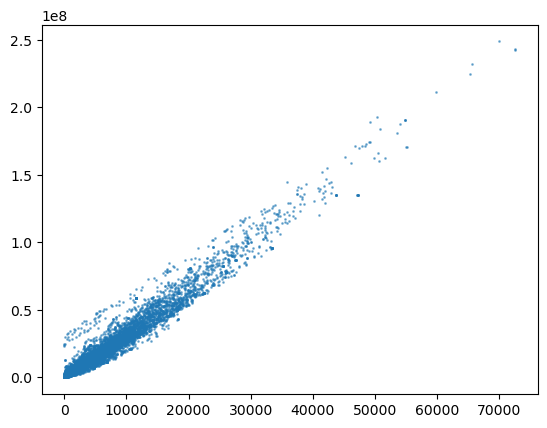

In [5]:
plt.scatter(df_CCLE_CNV_80.Num_Probes, df_CCLE_CNV_80.Length, alpha=0.5, s=1)

In [6]:
print("These cell lines are NOT in the CNV data:")
print(set(ccle_80_samples) - set(df_CCLE_CNV.cell_line.unique()))

These cell lines are NOT in the CNV data:
{'OVCAR5', 'HOP62', 'SNU1066'}


In [7]:
ccle_cnv = list(set(ccle_80_samples) & set(df_CCLE_CNV.cell_line.unique()))
ccle_cnv.sort()
print(len(ccle_cnv))
ccle_cnv[:5]

with open("./file_list_80_cnv.txt", "w") as f:
    for cl in ccle_cnv:
        f.write(cl + "\n")

77


In [14]:
ccle_80_samples

['639V',
 'A549',
 'AMO1',
 'BHT101',
 'BICR6',
 'BXPC3',
 'CA46',
 'COLO678',
 'CORL105',
 'DAOY',
 'DMS53',
 'HCC1187',
 'HCC1395',
 'HCC1954',
 'HCC366',
 'HCC44',
 'HEC6',
 'HOP62',
 'HPAFII',
 'HS578T',
 'HT55',
 'HUNS1',
 'IMR32',
 'ISTMES2',
 'JURLMK1',
 'K562',
 'KASUMI1',
 'KIJK',
 'KMRC2',
 'KOPN8',
 'KP3',
 'KPNYN',
 'KURAMOCHI',
 'KYSE270',
 'LCLC103H',
 'LN229',
 'LOUCY',
 'MCF7',
 'MDAMB231',
 'MEC1',
 'MFE296',
 'MJ',
 'MORCPR',
 'MUTZ5',
 'NALM6',
 'NCIH1648',
 'NCIH1944',
 'NCIH209',
 'NCIH2172',
 'NCIH2452',
 'NCIH727',
 'OV90',
 'OVCAR5',
 'P12ICHIKAWA',
 'PANC1',
 'PATU8902',
 'PATU8988T',
 'RH30',
 'RT112',
 'SKBR3',
 'SKNMC',
 'SNU1076',
 'SNU1079',
 'SNU349',
 'SNU407',
 'SNU5',
 'SNU620',
 'TE5',
 'TE6',
 'TE9',
 'U118MG',
 'UACC62',
 'UMUC3',
 'WM88',
 'YAPC',
 'YD38',
 'YD8',
 'CJM',
 'SNU1066',
 'VCAP']

for cl in df_CCLE_CNV_80.cell_line.unique():
    print(f"Processing {cl}...")
    df_cl = df_CCLE_CNV_80.loc[
        df_CCLE_CNV_80.cell_line == cl,
        [
            "Chromosome",
            "Start",
            "End",
            "cell_line",
            "Modal_Total_CN",
            "Homozygous_deletion",
            "Num_Probes",
            "Length",
        ],
    ].copy()

    # Check Overlap
    for chr in df_cl.Chromosome.unique():
        df_tmp = pd.DataFrame(
            {
                "end_1": df_cl.loc[df_cl.Chromosome == chr, "End"].iloc[:-1].values,
                "start_2": df_cl.loc[df_cl.Chromosome == chr, "End"].iloc[1:].values,
            }
        )
        if df_tmp.loc[df_tmp.end_1 > df_tmp.start_2, :].shape[0] > 0:
            print(f"Overlap detected in {cl} - {chr}")

    df_cl.to_csv(
        f"./CNV_per_cell_line/{cl}_CNV.tsv", sep="\t", index=False, header=False
    )

# Liftover (hg19 -> hg38)

# Initialize the conversion object
# This downloads the hg19ToHg38 chain file if not already present
lo = LiftOver("hg19", "hg38")

# Define your coordinates
chrom = ["chr1", "chr2"]
pos = [17246171, 43502477]  # Note: pyliftover uses 0-based coordinates

# Perform the conversion
new_coords = [lo.convert_coordinate(c, p) for c, p in zip(chrom, pos)]

for c, p, nc in zip(chrom, pos, new_coords):
    if nc:
        # nc is a list of tuples: (target_chromosome, target_position, strand, conversion_score)
        target_chrom, target_pos, strand, score = nc[0]
        print(f"hg19 {c}:{p} -> hg38 {target_chrom}:{target_pos}")
    else:
        print(
            f"Coordinate {c}:{p} could not be mapped to hg38 (likely deleted or heavily changed)."
        )

In [8]:
def lift_over_hg19_to_hg38(chrom, pos):
    lo = LiftOver("hg19", "hg38")
    new_coords = [lo.convert_coordinate(c, p) for c, p in zip(chrom, pos)]
    if new_coords:
        new_coords_chrs = []
        new_coords_poss = []
        for x in new_coords:
            if x:
                target_chrom, target_pos, strand, score = x[0]
                new_coords_chrs.append(target_chrom)
                new_coords_poss.append(target_pos)
            else:
                new_coords_chrs.append(None)
                new_coords_poss.append(None)
        df_out = pd.DataFrame(
            {
                "chr": chrom,
                "pos_bf": pos,
                "pos_af": new_coords_poss,
            }
        )

        return df_out
    else:
        return None, None

In [9]:
chrom = ["chr1", "chr2"]
pos = [17246171, 43502477]

lift_over_hg19_to_hg38(chrom, pos)

,chr,pos_bf,pos_af
0,chr1,17246171,16919676
1,chr2,43502477,43275338


# Convert to bed format

In [10]:
cmd = "mkdir -p ./CNV_per_cell_line"
os.system(cmd)

0

In [11]:
for cl in df_CCLE_CNV_80.cell_line.unique():
    print(f"Processing {cl}...")
    df_cl = df_CCLE_CNV_80.loc[
        df_CCLE_CNV_80.cell_line == cl,
        [
            "Chromosome",
            "Start",
            "End",
            "cell_line",
            "Modal_Total_CN",
            "Homozygous_deletion",
            "Num_Probes",
            "Length",
        ],
    ].copy()

    df_cl.Chromosome = "chr" + df_cl.Chromosome.astype(str)

    # Check Overlap
    for chr in df_cl.Chromosome.unique():
        df_tmp = pd.DataFrame(
            {
                "end_1": df_cl.loc[df_cl.Chromosome == chr, "End"].iloc[:-1].values,
                "start_2": df_cl.loc[df_cl.Chromosome == chr, "End"].iloc[1:].values,
            }
        )
        if df_tmp.loc[df_tmp.end_1 > df_tmp.start_2, :].shape[0] > 0:
            print(f"Overlap detected in {cl} - {chr}")

    # Before LiftOver,
    # save the CNV data for each cell line
    df_cl.to_csv(
        f"./CNV_per_cell_line/{cl}_CNV_hg19.tsv", sep="\t", index=False, header=False
    )

    # Run LiftOver,
    # LiftOver the coordinates from hg19 to hg38
    df_cl_lifted = df_cl.copy()
    df_cl_lifted.Start = lift_over_hg19_to_hg38(
        df_cl_lifted.Chromosome.tolist(), df_cl_lifted.Start.tolist()
    ).pos_af.values
    df_cl_lifted.End = lift_over_hg19_to_hg38(
        df_cl_lifted.Chromosome.tolist(), df_cl_lifted.End.tolist()
    ).pos_af.values

    df_cl_lifted.Start = df_cl_lifted.Start.astype("Int64")
    df_cl_lifted.End = df_cl_lifted.End.astype("Int64")

    df_cl_lifted.to_csv(
        f"./CNV_per_cell_line/{cl}_CNV_hg38.tsv",
        sep="\t",
        index=False,
        header=False,
    )

    # filter out rows with missing values in Start or End
    df_cl_lifted_filtered = df_cl_lifted.copy().dropna(subset=["Start", "End"])

    # filter out rows with Invalid (Start > End) coordinates
    df_cl_lifted_filtered = df_cl_lifted_filtered.loc[
        df_cl_lifted_filtered.Start < df_cl_lifted_filtered.End, :
    ]

    df_cl_lifted_filtered.to_csv(
        f"./CNV_per_cell_line/{cl}_CNV_hg38_filtered.tsv",
        sep="\t",
        index=False,
        header=False,
    )

Processing 639V...
Processing A549...
Processing AMO1...
Processing BHT101...
Processing BICR6...
Processing BXPC3...
Processing CA46...
Processing CJM...
Processing COLO678...
Processing CORL105...
Processing DAOY...
Processing DMS53...
Processing HCC1187...
Processing HCC1395...
Processing HCC1954...
Processing HCC366...
Processing HCC44...
Processing HEC6...
Processing HPAFII...
Processing HS578T...
Processing HT55...
Processing HUNS1...
Processing IMR32...
Processing ISTMES2...
Processing JURLMK1...
Processing K562...
Processing KASUMI1...
Processing KIJK...
Processing KMRC2...
Processing KOPN8...
Processing KP3...
Processing KPNYN...
Processing KURAMOCHI...
Processing KYSE270...
Processing LCLC103H...
Processing LN229...
Processing LOUCY...
Processing MCF7...
Processing MDAMB231...
Processing MEC1...
Processing MFE296...
Processing MJ...
Processing MORCPR...
Processing MUTZ5...
Processing NALM6...
Processing NCIH1648...
Processing NCIH1944...
Processing NCIH209...
Processing NCIH2

In [12]:
print(df_cl.shape)
df_cl.head()

(471, 8)


,Chromosome,Start,End,cell_line,Modal_Total_CN,Homozygous_deletion,Num_Probes,Length
187130,chr1,740857,9832932,YD8,2,0,2545,9092075
187131,chr1,9881112,10357406,YD8,2,0,71,476294
187132,chr1,10385471,12882985,YD8,2,0,614,2497514
187133,chr1,13793392,15789733,YD8,2,0,924,1996341
187134,chr1,15792426,16142960,YD8,2,0,78,350534


In [13]:
print(df_cl_lifted.shape)
df_cl_lifted.head()

(471, 8)


,Chromosome,Start,End,cell_line,Modal_Total_CN,Homozygous_deletion,Num_Probes,Length
187130,chr1,805477,9772874,YD8,2,0,2545,9092075
187131,chr1,9821054,10297348,YD8,2,0,71,476294
187132,chr1,10325413,12823122,YD8,2,0,614,2497514
187133,chr1,13466924,15463238,YD8,2,0,924,1996341
187134,chr1,15465931,15816465,YD8,2,0,78,350534
